In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


### Cleaning Dataset

In [20]:
# read the file
dfOriginal = pd.read_csv("Data/Post-Katrina_Damage_Assessment.csv", low_memory=False)

# clean column names
dfOriginal.columns = dfOriginal.columns.str.strip()

# remove duplicate rows
dfOriginal = dfOriginal.drop_duplicates()

# replace blank spaces with NaN
dfOriginal = dfOriginal.replace(r'^\s*$', np.nan, regex=True)

# replace common fake-missing values with NaN
dfOriginal = dfOriginal.replace(["Unknown", "unknown", "UNK", "-"], np.nan)

# convert columns to numeric when possible
for col in dfOriginal.columns:
    try:
        dfOriginal[col] = pd.to_numeric(dfOriginal[col])
    except:
        pass

# replace -1 with NaN in Percentage
if "Percentage" in dfOriginal.columns:
    dfOriginal["Percentage"] = dfOriginal["Percentage"].replace(-1, np.nan)

# fill numeric missing values with median
for col in dfOriginal.select_dtypes(include="number").columns:
    dfOriginal[col] = dfOriginal[col].fillna(dfOriginal[col].median())

# fill text missing values with "Unknown"
for col in dfOriginal.select_dtypes(include=["object", "string"]).columns:
    dfOriginal[col] = dfOriginal[col].fillna("Unknown")

# new cleaned dataset
df = dfOriginal.copy()

FileNotFoundError: [Errno 2] No such file or directory: 'Data/Post-Katrina_Damage_Assessment.csv'

### Intitial Analysis

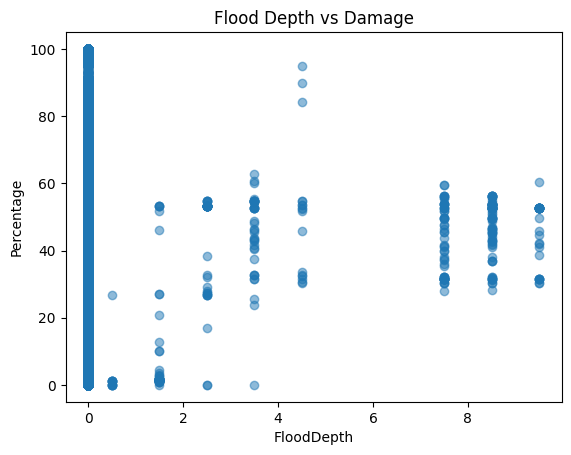

In [ ]:
#Flood depth vs damage
plt.figure()
plt.scatter(df["FloodDepth"], df["Percentage"], alpha=0.5)
plt.title("Flood Depth vs Damage")
plt.xlabel("FloodDepth")
plt.ylabel("Percentage")
plt.show()

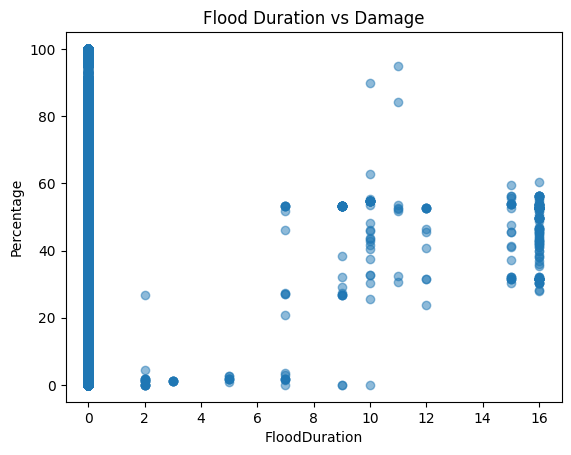

In [ ]:
#Flood duration vs damage
plt.figure()
plt.scatter(df["FloodDuration"], df["Percentage"], alpha=0.5)
plt.title("Flood Duration vs Damage")
plt.xlabel("FloodDuration")
plt.ylabel("Percentage")
plt.show()

In [ ]:
#Correlation with damage
corr = df.corr(numeric_only=True)
print("\nTop correlations with damage:")
print(corr["Percentage"].sort_values(ascending=False).head(10))


Top correlations with damage:
Percentage                                  1.000000
InteriorFinish_Plaster_Drywall_DamagePer    0.907239
InsulationandWeatherStripping_DamagePer     0.897516
LumberFinished_DamagePer                    0.887283
Doors_Windows_Shutters_DamagePer            0.887249
Heating_Cooling_DamagePer                   0.878936
Electrical_DamagePer                        0.854287
Plumbing_DamagePer                          0.826922
Floor_Covering_DamagePer                    0.821110
Builtin_Appliances_DamagePer                0.792010
Name: Percentage, dtype: float64


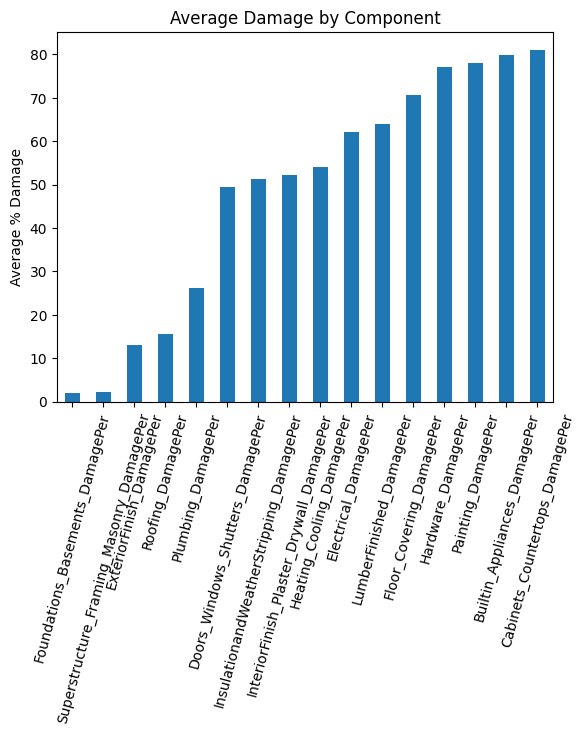

In [ ]:
#Average damage by component
damage_cols = [col for col in df.columns if "DamagePer" in col]
avg_damage = df[damage_cols].mean().sort_values()
plt.figure()
avg_damage.plot(kind="bar")
plt.title("Average Damage by Component")
plt.ylabel("Average % Damage")
plt.xticks(rotation=75)
plt.show()

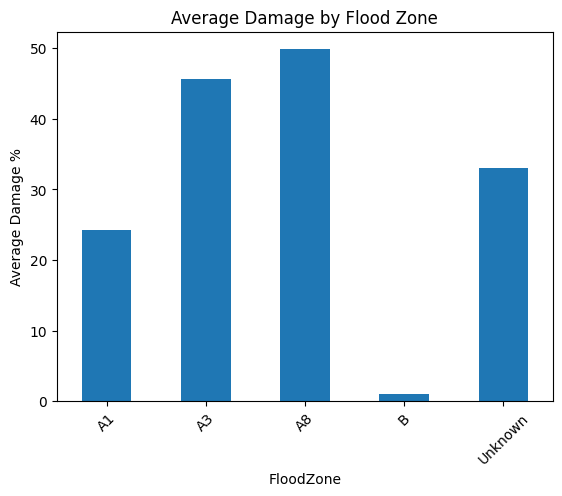

In [ ]:
#Flood zone comparison
if "FloodZone" in df.columns:
    plt.figure()
    df.groupby("FloodZone")["Percentage"].mean().plot(kind="bar")
    plt.title("Average Damage by Flood Zone")
    plt.ylabel("Average Damage %")
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
import pandas as pd

katrina = pd.read_csv("Post-Katrina_Damage_Assessment.csv")
print(katrina.columns)
katrina.head()

Index(['Address', 'Percentage', 'Foundations_Basements',
       'Superstructure_Framing_Masonry', 'Roofing',
       'InsulationandWeatherStripping', 'ExteriorFinish',
       'InteriorFinish_Plaster_Drywall', 'Doors_Windows_Shutters',
       'LumberFinished', 'Hardware', 'Cabinets_Countertops', 'Floor_Covering',
       'Plumbing', 'Electrical', 'Builtin_Appliances', 'Heating_Cooling',
       'Painting', 'Foundations_Basements_DamagePer',
       'Superstructure_Framing_Masonry_DamagePer', 'Roofing_DamagePer',
       'InsulationandWeatherStripping_DamagePer', 'ExteriorFinish_DamagePer',
       'InteriorFinish_Plaster_Drywall_DamagePer',
       'Doors_Windows_Shutters_DamagePer', 'LumberFinished_DamagePer',
       'Hardware_DamagePer', 'Cabinets_Countertops_DamagePer',
       'Floor_Covering_DamagePer', 'Plumbing_DamagePer',
       'Electrical_DamagePer', 'Builtin_Appliances_DamagePer',
       'Heating_Cooling_DamagePer', 'Painting_DamagePer', 'FloodDepth',
       'FloodDuration', 'FloodZo

/var/folders/v_/crprn84x4z3fglfytz4l1s9m0000gn/T/ipykernel_27681/20147422.py:3: DtypeWarning: Columns (0: FloodZone, 1: Add6, 2: Add7, 3: Add8, 4: Add9, 5: Add10, 6: Add11, 7: Add12, 8: Add17, 9: Add18) have mixed types. Specify dtype option on import or set low_memory=False.
  katrina = pd.read_csv("Post-Katrina_Damage_Assessment.csv")


,Address,Percentage,Foundations_Basements,Superstructure_Framing_Masonry,Roofing,InsulationandWeatherStripping,ExteriorFinish,InteriorFinish_Plaster_Drywall,Doors_Windows_Shutters,LumberFinished,...,Add10,Add11,Add12,Add13,Add14,Add15,Add16,Add17,Add18,Add19
0,ANDRY ST,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ANNUNCIATION ST,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AUDUBON CT,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AUDUBON ST,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,BELMONT PL,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
hpi = pd.read_csv("hpi_at_us_and_census.csv")
print(hpi.columns)
hpi.head()

Index(['DV_ENC', '1975', '1', '63.65'], dtype='str')


,DV_ENC,1975,1,63.65
0,DV_ENC,1975,2,62.64
1,DV_ENC,1975,3,63.61
2,DV_ENC,1975,4,65.05
3,DV_ENC,1976,1,65.05
4,DV_ENC,1976,2,66.98


In [ ]:
import pandas as pd

katrina = pd.read_csv("Post-Katrina_Damage_Assessment.csv")

# keep only useful columns
katrina = katrina[['FloodDepth', 'Percentage']]

# clean
katrina = katrina.dropna()

# convert to numeric (VERY IMPORTANT)
katrina['FloodDepth'] = pd.to_numeric(katrina['FloodDepth'], errors='coerce')
katrina['Percentage'] = pd.to_numeric(katrina['Percentage'], errors='coerce')

katrina = katrina.dropna()

katrina.head()

/var/folders/v_/crprn84x4z3fglfytz4l1s9m0000gn/T/ipykernel_27681/3147126199.py:3: DtypeWarning: Columns (0: FloodZone, 1: Add6, 2: Add7, 3: Add8, 4: Add9, 5: Add10, 6: Add11, 7: Add12, 8: Add17, 9: Add18) have mixed types. Specify dtype option on import or set low_memory=False.
  katrina = pd.read_csv("Post-Katrina_Damage_Assessment.csv")


,FloodDepth,Percentage
96,0.0,20.38
112,0.0,53.30
118,0.0,20.38
135,0.0,35.43
137,0.0,30.46


In [ ]:
katrina.describe()

,FloodDepth,Percentage
count,100193.000000,100193.000000
mean,0.019472,32.531207
std,0.376448,22.304885
min,0.000000,0.000000
25%,0.000000,16.330000
50%,0.000000,33.650000
75%,0.000000,49.690000
max,9.500000,100.000000


In [ ]:
from scipy.stats import linregress

result = linregress(katrina['FloodDepth'], katrina['Percentage'])

print("Slope:", result.slope)
print("Intercept:", result.intercept)
print("R-squared:", result.rvalue**2)
print("P-value:", result.pvalue)
print("Standard error:", result.stderr)

Slope: 1.6391295359186362
Intercept: 32.49928875545619
R-squared: 0.0007653080462974355
P-value: 1.9840456353064345e-18
Standard error: 0.1871175543306407


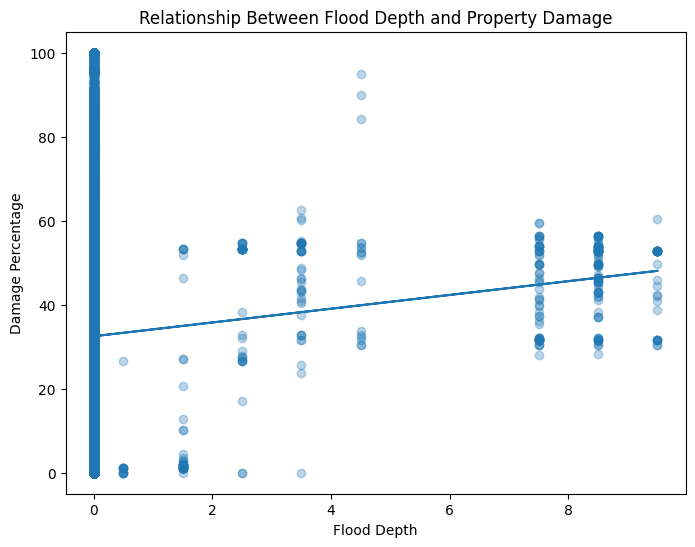

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = katrina['FloodDepth'].values
y = katrina['Percentage'].values

slope, intercept = np.polyfit(x, y, 1)

plt.figure(figsize=(8,6))
plt.scatter(x, y, alpha=0.3)
plt.plot(x, slope*x + intercept)
plt.xlabel("Flood Depth")
plt.ylabel("Damage Percentage")
plt.title("Relationship Between Flood Depth and Property Damage")
plt.show()

In [ ]:
hpi = pd.read_csv("hpi_at_state.csv")

# filter for Louisiana
la = hpi[hpi['state'] == 'LA']

plt.plot(la['year'], la['index_sa'])
plt.axvline(x=2005, linestyle='--')  # Katrina
plt.title("Louisiana Housing Prices Over Time")
plt.xlabel("Year")
plt.ylabel("HPI")
plt.show()

KeyError: 'state'

In [ ]:
high_flood = katrina[katrina['FloodDepth'] > 3]
low_flood = katrina[katrina['FloodDepth'] <= 3]

***QUESTION 1***: _What is the relationship between flood depth and property damage following Hurricane Katrina, and what does this reveal about the predictability of flood-related risk?_

**Cell 1 — imports**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

**Cell 2 — load and inspect the dataset**

In [ ]:
katrina_raw = pd.read_csv("Post-Katrina_Damage_Assessment.csv")

print("Shape:", katrina_raw.shape)
print("\nColumns:\n", katrina_raw.columns.tolist())

katrina_raw.head()

Shape: (165564, 59)

Columns:
 ['Address', 'Percentage', 'Foundations_Basements', 'Superstructure_Framing_Masonry', 'Roofing', 'InsulationandWeatherStripping', 'ExteriorFinish', 'InteriorFinish_Plaster_Drywall', 'Doors_Windows_Shutters', 'LumberFinished', 'Hardware', 'Cabinets_Countertops', 'Floor_Covering', 'Plumbing', 'Electrical', 'Builtin_Appliances', 'Heating_Cooling', 'Painting', 'Foundations_Basements_DamagePer', 'Superstructure_Framing_Masonry_DamagePer', 'Roofing_DamagePer', 'InsulationandWeatherStripping_DamagePer', 'ExteriorFinish_DamagePer', 'InteriorFinish_Plaster_Drywall_DamagePer', 'Doors_Windows_Shutters_DamagePer', 'LumberFinished_DamagePer', 'Hardware_DamagePer', 'Cabinets_Countertops_DamagePer', 'Floor_Covering_DamagePer', 'Plumbing_DamagePer', 'Electrical_DamagePer', 'Builtin_Appliances_DamagePer', 'Heating_Cooling_DamagePer', 'Painting_DamagePer', 'FloodDepth', 'FloodDuration', 'FloodZone', 'PropertyDescription', 'Owner', 'TaxBill', 'Add1', 'Add2', 'Add3', 'Add4', 

/var/folders/v_/crprn84x4z3fglfytz4l1s9m0000gn/T/ipykernel_27681/3618053420.py:1: DtypeWarning: Columns (0: FloodZone, 1: Add6, 2: Add7, 3: Add8, 4: Add9, 5: Add10, 6: Add11, 7: Add12, 8: Add17, 9: Add18) have mixed types. Specify dtype option on import or set low_memory=False.
  katrina_raw = pd.read_csv("Post-Katrina_Damage_Assessment.csv")


,Address,Percentage,Foundations_Basements,Superstructure_Framing_Masonry,Roofing,InsulationandWeatherStripping,ExteriorFinish,InteriorFinish_Plaster_Drywall,Doors_Windows_Shutters,LumberFinished,...,Add10,Add11,Add12,Add13,Add14,Add15,Add16,Add17,Add18,Add19
0,ANDRY ST,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ANNUNCIATION ST,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AUDUBON CT,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AUDUBON ST,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,BELMONT PL,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Cell 3 — keep only the variables needed for Question 1**

In [ ]:
katrina = katrina_raw[['FloodDepth', 'Percentage']].copy()

print("Initial shape:", katrina.shape)
katrina.head()

Initial shape: (165564, 2)


,FloodDepth,Percentage
0,NaN,-1.0
1,NaN,-1.0
2,NaN,-1.0
3,NaN,-1.0
4,NaN,-1.0


Cell 4 — clean the data properly

In [21]:
# Convert both columns to numeric
katrina['FloodDepth'] = pd.to_numeric(katrina['FloodDepth'], errors='coerce')
katrina['Percentage'] = pd.to_numeric(katrina['Percentage'], errors='coerce')

# Drop missing values
katrina = katrina.dropna()

# Remove invalid damage percentages
# In your data, -1 appears to mean invalid / missing, so remove it
katrina = katrina[katrina['Percentage'] >= 0]

# Keep only logically valid damage percentages between 0 and 100
katrina = katrina[(katrina['Percentage'] >= 0) & (katrina['Percentage'] <= 100)]

# Keep only nonnegative flood depth
katrina = katrina[katrina['FloodDepth'] >= 0]

print("Cleaned shape:", katrina.shape)
katrina.head()

Cleaned shape: (100193, 2)


,FloodDepth,Percentage
96,0.0,20.38
112,0.0,53.30
118,0.0,20.38
135,0.0,35.43
137,0.0,30.46


**Cell 5**

In [22]:
print(katrina.describe())

print("\nNumber of homes with FloodDepth = 0:", (katrina['FloodDepth'] == 0).sum())
print("Number of homes with FloodDepth > 0:", (katrina['FloodDepth'] > 0).sum())

          FloodDepth     Percentage
count  100193.000000  100193.000000
mean        0.019472      32.531207
std         0.376448      22.304885
min         0.000000       0.000000
25%         0.000000      16.330000
50%         0.000000      33.650000
75%         0.000000      49.690000
max         9.500000     100.000000

Number of homes with FloodDepth = 0: 99847
Number of homes with FloodDepth > 0: 346


**Cell 6**

In [23]:
result_all = linregress(katrina['FloodDepth'], katrina['Percentage'])

print("MAIN REGRESSION: FULL CLEANED DATA")
print("Slope:", result_all.slope)
print("Intercept:", result_all.intercept)
print("R-squared:", result_all.rvalue**2)
print("P-value:", result_all.pvalue)
print("Standard error:", result_all.stderr)

MAIN REGRESSION: FULL CLEANED DATA
Slope: 1.6391295359186362
Intercept: 32.49928875545619
R-squared: 0.0007653080462974355
P-value: 1.9840456353064345e-18
Standard error: 0.1871175543306407


**Cell 7**

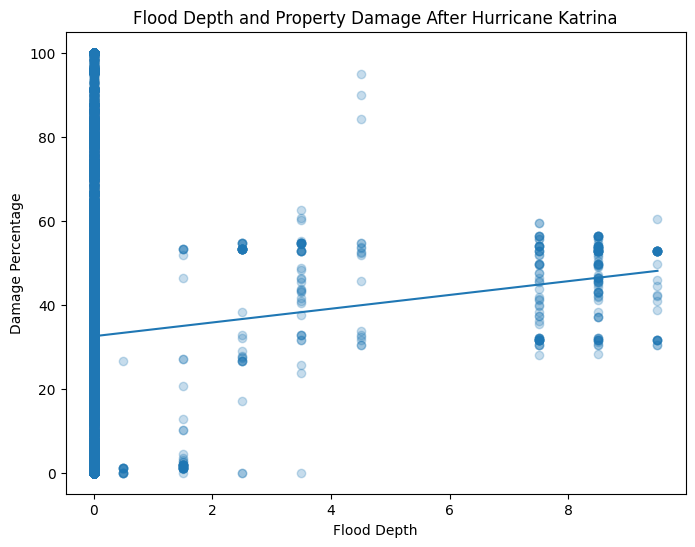

In [24]:
x_all = katrina['FloodDepth'].values
y_all = katrina['Percentage'].values

slope_all, intercept_all = np.polyfit(x_all, y_all, 1)

plt.figure(figsize=(8, 6))
plt.scatter(x_all, y_all, alpha=0.25)
plt.plot(np.sort(x_all), slope_all * np.sort(x_all) + intercept_all)
plt.xlabel("Flood Depth")
plt.ylabel("Damage Percentage")
plt.title("Flood Depth and Property Damage After Hurricane Katrina")
plt.show()

**Cell 8**

In [25]:
depth_summary = (
    katrina.groupby('FloodDepth', as_index=False)['Percentage']
    .mean()
    .sort_values('FloodDepth')
)

print(depth_summary)

   FloodDepth  Percentage
0         0.0   32.508614
1         0.5    2.491429
2         1.5   10.010833
3         2.5   42.991538
4         3.5   46.099524
5         4.5   51.728824
6         7.5   42.996452
7         8.5   47.589783
8         9.5   45.622500


**Cell 9**

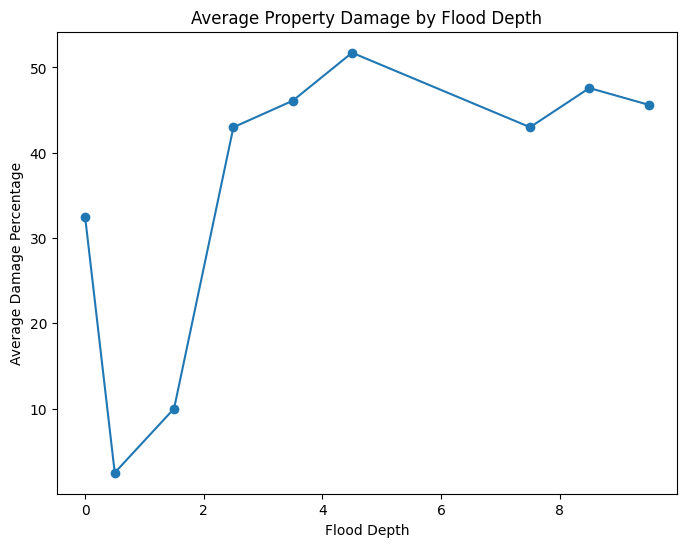

In [26]:
plt.figure(figsize=(8, 6))
plt.plot(depth_summary['FloodDepth'], depth_summary['Percentage'], marker='o')
plt.xlabel("Flood Depth")
plt.ylabel("Average Damage Percentage")
plt.title("Average Property Damage by Flood Depth")
plt.show()

**Cell 10**

In [27]:
katrina_positive = katrina[katrina['FloodDepth'] > 0].copy()

print("Positive-depth-only shape:", katrina_positive.shape)
print(katrina_positive.describe())

Positive-depth-only shape: (346, 2)
       FloodDepth  Percentage
count  346.000000  346.000000
mean     5.638728   39.050867
std      3.062319   19.035227
min      0.500000    0.000000
25%      2.500000   31.650000
50%      7.500000   46.055000
75%      8.500000   53.230000
max      9.500000   95.040000


**Cell 11**

In [28]:
result_pos = linregress(katrina_positive['FloodDepth'], katrina_positive['Percentage'])

print("SENSITIVITY REGRESSION: FLOOD DEPTH > 0 ONLY")
print("Slope:", result_pos.slope)
print("Intercept:", result_pos.intercept)
print("R-squared:", result_pos.rvalue**2)
print("P-value:", result_pos.pvalue)
print("Standard error:", result_pos.stderr)

SENSITIVITY REGRESSION: FLOOD DEPTH > 0 ONLY
Slope: 3.26189364568333
Intercept: 20.65793496321336
R-squared: 0.27537495795063716
P-value: 7.073502176797788e-26
Standard error: 0.2852889974335789


**Cell 12**

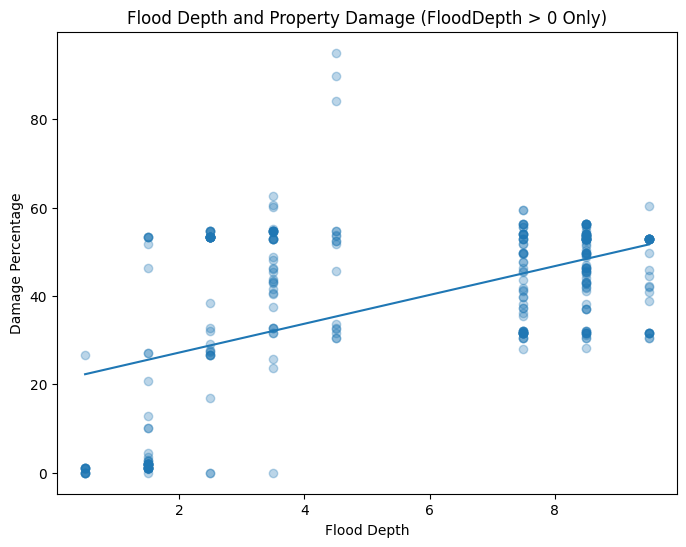

In [29]:
x_pos = katrina_positive['FloodDepth'].values
y_pos = katrina_positive['Percentage'].values

slope_pos, intercept_pos = np.polyfit(x_pos, y_pos, 1)

plt.figure(figsize=(8, 6))
plt.scatter(x_pos, y_pos, alpha=0.30)
plt.plot(np.sort(x_pos), slope_pos * np.sort(x_pos) + intercept_pos)
plt.xlabel("Flood Depth")
plt.ylabel("Damage Percentage")
plt.title("Flood Depth and Property Damage (FloodDepth > 0 Only)")
plt.show()

**Cell 13 — correlation**

In [30]:
corr_all = katrina['FloodDepth'].corr(katrina['Percentage'])
corr_pos = katrina_positive['FloodDepth'].corr(katrina_positive['Percentage'])

print("Correlation (full cleaned data):", corr_all)
print("Correlation (FloodDepth > 0 only):", corr_pos)

Correlation (full cleaned data): 0.027664201530090037
Correlation (FloodDepth > 0 only): 0.5247618106823677
